# EDAノートブック

本ノートブックは、分析業務で使うEDAを固定手順で実行するための定型版です。
可視化結果は相対パスで `reports/figures` に保存します。


## 固定EDA計画
1. データ読み込みと基本確認
2. 列型・記述統計の確認
3. 欠損率の集計と可視化
4. 数値列の分布確認
5. カテゴリ列の主要分布確認
6. 目的変数の分布と偏り確認
7. 数値特徴量の相関確認
8. 日付列の時系列傾向確認（存在時）
9. 観察結果サマリ


In [1]:
from pathlib import Path
import warnings

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")
warnings.filterwarnings("ignore", message="Glyph .* missing from font")
plt.rcParams["axes.unicode_minus"] = False

JP_FONT_CANDIDATES = [
    "Yu Gothic",
    "Meiryo",
    "MS Gothic",
    "Noto Sans CJK JP",
    "IPAexGothic",
    "IPAGothic",
    "TakaoGothic",
]


def configure_japanese_font() -> str:
    available = {f.name for f in fm.fontManager.ttflist}
    for name in JP_FONT_CANDIDATES:
        if name in available:
            plt.rcParams["font.family"] = name
            return name
    plt.rcParams["font.sans-serif"] = JP_FONT_CANDIDATES + list(plt.rcParams.get("font.sans-serif", []))
    return ""


selected_font = configure_japanese_font()
if selected_font:
    print(f"日本語フォント: {selected_font}")
else:
    print("日本語フォント候補が見つからないため、既定フォントで描画します。")

ENCODINGS = ("utf-8-sig", "utf-8", "cp932", "shift_jis", "euc_jp")

cwd = Path.cwd()
if (cwd / "configs" / "project_config.json").exists():
    analysis_root = cwd
elif (cwd.name == "notebooks") and (cwd.parent / "configs" / "project_config.json").exists():
    analysis_root = cwd.parent
elif (cwd / "artifacts" / "analysis_project" / "configs" / "project_config.json").exists():
    analysis_root = cwd / "artifacts" / "analysis_project"
else:
    analysis_root = cwd

FIG_DIR = analysis_root / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def load_csv_auto(path: Path):
    sep = "	" if path.suffix.lower() == ".tsv" else ","
    for enc in ENCODINGS:
        try:
            return pd.read_csv(path, encoding=enc, sep=sep), enc
        except UnicodeDecodeError:
            continue
    raise RuntimeError("CSVを既知エンコーディングで読み込めませんでした")


def is_pure_day_number_column(series: pd.Series) -> bool:
    numeric = pd.to_numeric(series, errors="coerce").dropna()
    if numeric.empty:
        return False
    if not np.all(np.isclose(numeric, np.round(numeric))):
        return False
    return bool(((numeric >= 1) & (numeric <= 31)).all())


日本語フォント: Yu Gothic


In [2]:
csv_rel = Path("data/train.csv")
candidates = [
    analysis_root / csv_rel,
    Path("data/train.csv"),
    Path("artifacts/analysis_project") / csv_rel,
]
csv_path = next((p for p in candidates if p.exists()), candidates[0])
df, used_encoding = load_csv_auto(csv_path)
target_col = "target"
if target_col not in df.columns:
    target_col = df.columns[-1]
date_col_hint = "None".strip() or None

print(f"読み込みエンコーディング: {used_encoding}")
print(f"行数: {len(df):,} / 列数: {df.shape[1]:,}")
print(f"目的変数列: {target_col}")
display(df.head(10))


読み込みエンコーディング: utf-8-sig
行数: 11,529 / 列数: 10
目的変数列: target


,id,Gender,Age,Country,Education,Major,Profession,Industry,Experience,target
0,train_00000,Female,25-29,United States of America,Master’s degree,Engineering (non-computer focused),Data Analyst,Medical/Pharmaceutical,1-2,4
1,train_00001,Male,22-24,India,Bachelor’s degree,Other,Data Scientist,Accounting/Finance,1-2,0
2,train_00002,Male,30-34,United States of America,Doctoral degree,"Computer science (software engineering, etc.)",Research Assistant,I am a student,4-5,1
3,train_00003,Male,30-34,India,Some college/university study without earning ...,"Social sciences (anthropology, psychology, soc...",Data Analyst,Government/Public Service,1-2,1
4,train_00004,Male,25-29,Japan,Some college/university study without earning ...,"A business discipline (accounting, economics, ...",Software Engineer,Online Service/Internet-based Services,3-4,3
5,train_00005,Male,35-39,Italy,Master’s degree,Mathematics or statistics,Other,Other,10-15,3
6,train_00006,Male,30-34,Germany,Doctoral degree,"Medical or life sciences (biology, chemistry, ...",Research Scientist,Medical/Pharmaceutical,2-3,2
7,train_00007,Male,22-24,United States of America,Doctoral degree,Physics or astronomy,Student,I am a student,2-3,2
8,train_00008,Male,40-44,Other,Doctoral degree,Mathematics or statistics,Data Scientist,Academics/Education,2-3,1
9,train_00009,Male,30-34,Australia,Doctoral degree,Physics or astronomy,Data Scientist,Academics/Education,2-3,4


## 1. データ概要


In [3]:
try:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from pathlib import Path

    print('===== データ概要 =====')
    print(f'行数: {df.shape[0]}')
    print(f'列数: {df.shape[1]}')
    print('\n列名一覧:')
    print(df.columns.tolist())

    print('\nデータ型:')
    print(df.dtypes)

    print('\n先頭5行:')
    print(df.head())

    print('\n基本統計量（数値列）:')
    num_df = df.select_dtypes(include=[np.number])
    if target_col in df.columns and target_col not in num_df.columns:
        target_num = pd.to_numeric(df[target_col], errors='coerce')
        if target_num.notna().sum() > 0:
            num_df = pd.concat([num_df, target_num.rename(target_col)], axis=1)
            num_df = num_df.loc[:, ~num_df.columns.duplicated()]
    if num_df.shape[1] > 0:
        print(num_df.describe().T)

    print('\n基本統計量（カテゴリ列）:')
    cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    if len(cat_cols) > 0:
        print(df[cat_cols].astype(str).describe().T)

    print('\n欠損数:')
    print(df.isnull().sum().sort_values(ascending=False))

    print('\nユニーク数:')
    print(df.nunique(dropna=False).sort_values(ascending=False))
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: overview_code: {_eda_exc}")
    dtype_summary = (
        df.dtypes.astype(str)
        .rename("dtype")
        .reset_index()
        .rename(columns={"index": "column"})
    )
    type_counts = dtype_summary["dtype"].value_counts().rename_axis("dtype").reset_index(name="count")
    print("列型サマリ")
    display(type_counts)
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    category_cols = [c for c in df.columns if c not in numeric_cols]
    print(f"数値列数: {len(numeric_cols)} / カテゴリ列数: {len(category_cols)}")
    display(dtype_summary.head(30))


===== データ概要 =====
行数: 11529
列数: 10

列名一覧:
['id', 'Gender', 'Age', 'Country', 'Education', 'Major', 'Profession', 'Industry', 'Experience', 'target']

データ型:
id              str
Gender          str
Age             str
Country         str
Education       str
Major           str
Profession      str
Industry        str
Experience      str
target        int64
dtype: object

先頭5行:
            id  Gender    Age                   Country  \
0  train_00000  Female  25-29  United States of America   
1  train_00001    Male  22-24                     India   
2  train_00002    Male  30-34  United States of America   
3  train_00003    Male  30-34                     India   
4  train_00004    Male  25-29                     Japan   

                                           Education  \
0                                    Master’s degree   
1                                  Bachelor’s degree   
2                                    Doctoral degree   
3  Some college/university study without ear

            count unique                                            top  freq
id          11529  11529                                    train_00000     1
Gender      11529      4                                           Male  9551
Age         11529     12                                          25-29  3293
Country     11529     58                       United States of America  2575
Education   11529      7                                Master’s degree  5536
Major       11417     13  Computer science (software engineering, etc.)  4137
Profession  11529     20                                 Data Scientist  2509
Industry    11529     19                           Computers/Technology  3090
Experience  11474     11                                            0-1  2728

欠損数:
Major         112
Experience     55
Gender          0
id              0
Country         0
Age             0
Education       0
Profession      0
Industry        0
target          0
dtype: int64

ユニーク数:


id            11529
Country          58
Profession       20
Industry         19
Major            14
Experience       12
Age              12
Education         7
target            6
Gender            4
dtype: int64


C:\Users\hikeshita\AppData\Local\Temp\ipykernel_6848\2628615718.py:31: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


## 2. 欠損分析


===== 欠損値確認 =====


            欠損数    欠損率(%)
Major       112  0.971463
Experience   55  0.477058


C:\Users\hikeshita\AppData\Local\Temp\ipykernel_6848\610875534.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df.reset_index(), x='欠損率(%)', y='index', palette='Reds_r')


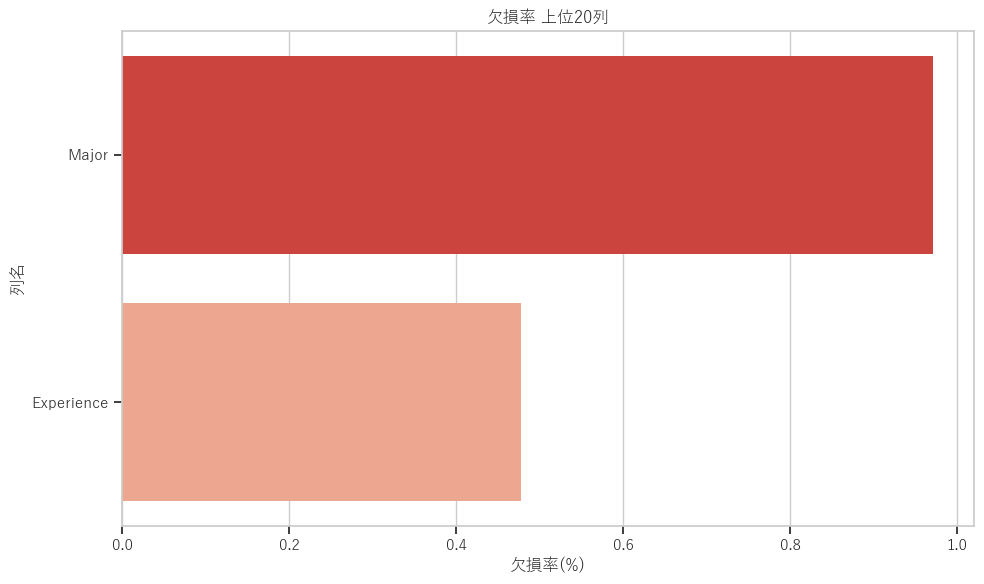

In [4]:
try:
    from pathlib import Path

    missing_count = df.isnull().sum()
    missing_rate = (missing_count / len(df) * 100).sort_values(ascending=False)
    missing_df = pd.DataFrame({'欠損数': missing_count, '欠損率(%)': missing_rate}).sort_values('欠損率(%)', ascending=False)
    print('===== 欠損値確認 =====')
    print(missing_df[missing_df['欠損数'] > 0])

    plot_df = missing_df[missing_df['欠損数'] > 0].head(20)
    plt.figure(figsize=(10, 6))
    if len(plot_df) > 0:
        sns.barplot(data=plot_df.reset_index(), x='欠損率(%)', y='index', palette='Reds_r')
        plt.xlabel('欠損率(%)')
        plt.ylabel('列名')
        plt.title('欠損率 上位20列')
    else:
        plt.text(0.5, 0.5, '欠損列はありません', ha='center', va='center', fontsize=14)
        plt.title('欠損率 上位20列')
        plt.axis('off')
    plt.tight_layout()
    plt.savefig(Path(FIG_DIR) / 'missing_rate_top20.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: missing_code: {_eda_exc}")
    missing_rate = (df.isna().mean() * 100).sort_values(ascending=False)
    display(missing_rate.rename("欠損率(%)").to_frame().head(20))
    top_missing = missing_rate.head(20)
    fig, ax = plt.subplots(figsize=(12, 5))
    top_missing.plot(kind="bar", ax=ax, color="#4c78a8")
    ax.set_title("欠損率 上位20列")
    ax.set_ylabel("欠損率(%)")
    ax.set_xlabel("列名")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "missing_rate_top20.png", dpi=160, bbox_inches="tight")
    plt.show()


## 3. 数値特徴量の分布


===== 数値列分布 =====
          count     mean       std  min  25%  50%  75%  max
target  11529.0  1.95082  1.653784  0.0  0.0  2.0  3.0  5.0


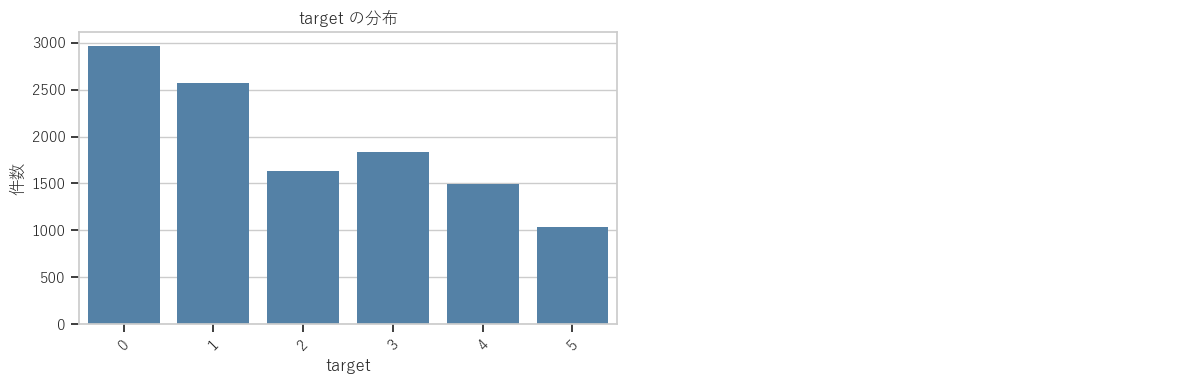

In [5]:
try:
    from pathlib import Path
    import math

    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if target_col in df.columns and target_col not in num_cols:
        tmp_target = pd.to_numeric(df[target_col], errors='coerce')
        if tmp_target.notna().sum() > 0:
            df_num_plot = df.copy()
            df_num_plot[target_col] = tmp_target
            num_cols = df_num_plot.select_dtypes(include=[np.number]).columns.tolist()
        else:
            df_num_plot = df.copy()
    else:
        df_num_plot = df.copy()

    plot_cols = num_cols[:6]
    print('===== 数値列分布 =====')
    if len(plot_cols) > 0:
        print(df_num_plot[plot_cols].describe().T)

    n = max(len(plot_cols), 1)
    rows = math.ceil(n / 2)
    fig, axes = plt.subplots(rows, 2, figsize=(12, 4 * rows))
    axes = np.array(axes).reshape(-1)

    if len(plot_cols) > 0:
        for i, col in enumerate(plot_cols):
            series = pd.to_numeric(df_num_plot[col], errors='coerce').dropna()
            ax = axes[i]
            if series.nunique() <= 15:
                vc = series.value_counts().sort_index()
                sns.barplot(x=vc.index.astype(str), y=vc.values, ax=ax, color='steelblue')
                ax.set_ylabel('件数')
                ax.set_xlabel(col)
                ax.set_title(f'{col} の分布')
                ax.tick_params(axis='x', rotation=45)
            else:
                sns.histplot(series, kde=True, ax=ax, color='steelblue')
                ax.set_xlabel(col)
                ax.set_ylabel('度数')
                ax.set_title(f'{col} の分布')
        for j in range(len(plot_cols), len(axes)):
            axes[j].axis('off')
    else:
        axes[0].text(0.5, 0.5, '数値列がありません', ha='center', va='center', fontsize=14)
        axes[0].set_title('数値列の分布')
        axes[0].axis('off')
        for j in range(1, len(axes)):
            axes[j].axis('off')

    plt.tight_layout()
    plt.savefig(Path(FIG_DIR) / 'numeric_distribution_top6.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: numeric_code: {_eda_exc}")
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    if numeric_cols:
        display(df[numeric_cols].describe().T.head(20))
    target_col_local = "target"
    if target_col_local not in df.columns:
        target_col_local = df.columns[-1]
    plot_cols = [c for c in numeric_cols if c != target_col_local][:6]
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    for i, ax in enumerate(axes):
        if i < len(plot_cols):
            col = plot_cols[i]
            sns.histplot(df[col], bins=30, ax=ax, color="#1f77b4")
            ax.set_title(f"{col} の分布")
        else:
            ax.axis("off")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "numeric_distribution_top6.png", dpi=160, bbox_inches="tight")
    plt.show()


## 4. カテゴリ特徴量の分布


C:\Users\hikeshita\AppData\Local\Temp\ipykernel_6848\3649691661.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
C:\Users\hikeshita\AppData\Local\Temp\ipykernel_6848\3649691661.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.values, y=vc.index, ax=axes[i], palette='viridis')


===== カテゴリ列分布 =====

[Gender]
Gender
Male                       9551
Female                     1844
Prefer not to say            97
Prefer to self-describe      37
Name: count, dtype: int64

[Age]
Age
25-29    3293
30-34    2223
22-24    2045
35-39    1252
18-21     793
40-44     784
45-49     472
50-54     327
55-59     170
60-69     142
Name: count, dtype: int64

[Country]
Country
United States of America                                2575
India                                                   1395
China                                                    599
Other                                                    527
Russia                                                   462
Brazil                                                   439
Germany                                                  397
United Kingdom of Great Britain and Northern Ireland     383
Canada                                                   353
Japan                                                    325
Nam

C:\Users\hikeshita\AppData\Local\Temp\ipykernel_6848\3649691661.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.values, y=vc.index, ax=axes[i], palette='viridis')


C:\Users\hikeshita\AppData\Local\Temp\ipykernel_6848\3649691661.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.values, y=vc.index, ax=axes[i], palette='viridis')


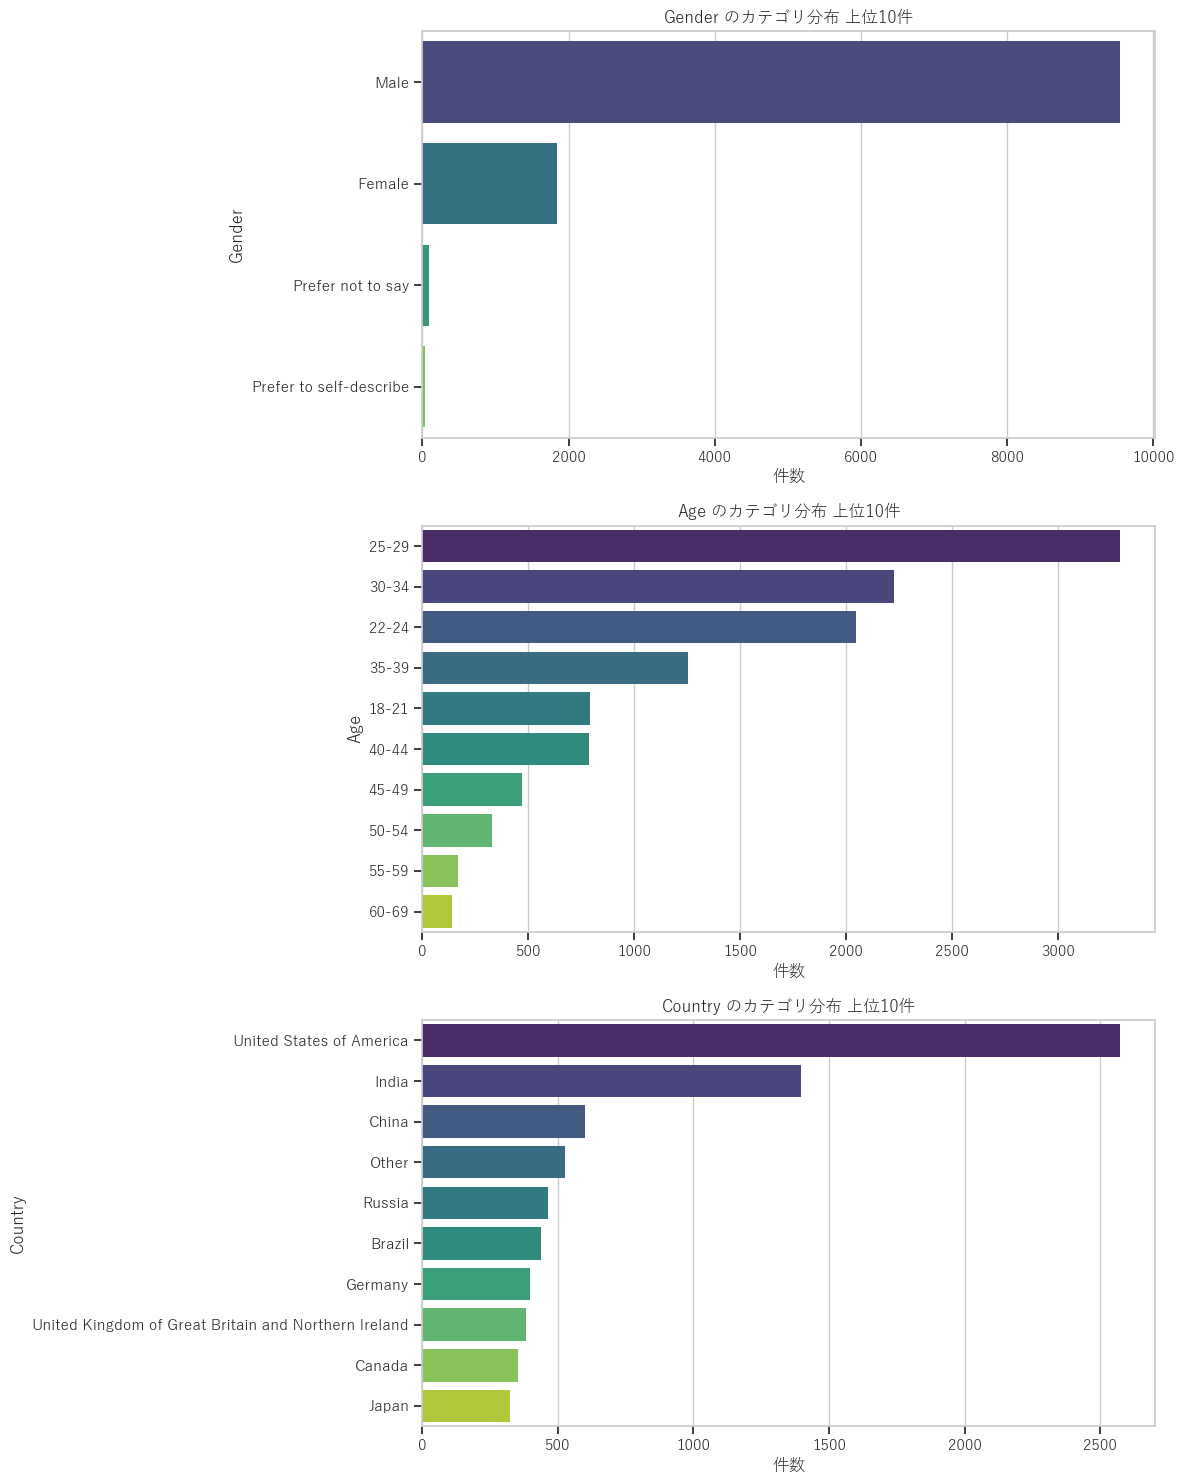

In [6]:
try:
    from pathlib import Path
    import math

    cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    cat_cols = [c for c in cat_cols if c != target_col]
    cat_priority = []
    for c in ['Gender', 'Age', 'Country', 'Education', 'Major', 'Profession', 'Industry', 'Experience', 'id']:
        if c in cat_cols:
            cat_priority.append(c)
    for c in cat_cols:
        if c not in cat_priority:
            cat_priority.append(c)
    plot_cols = cat_priority[:3]

    print('===== カテゴリ列分布 =====')
    for col in plot_cols:
        print(f'\n[{col}]')
        print(df[col].astype(str).value_counts(dropna=False).head(10))

    n = max(len(plot_cols), 1)
    fig, axes = plt.subplots(n, 1, figsize=(12, 5 * n))
    axes = np.array(axes).reshape(-1)

    if len(plot_cols) > 0:
        for i, col in enumerate(plot_cols):
            vc = df[col].astype(str).fillna('欠損').value_counts(dropna=False).head(10)
            sns.barplot(x=vc.values, y=vc.index, ax=axes[i], palette='viridis')
            axes[i].set_xlabel('件数')
            axes[i].set_ylabel(col)
            axes[i].set_title(f'{col} のカテゴリ分布 上位10件')
    else:
        axes[0].text(0.5, 0.5, 'カテゴリ列がありません', ha='center', va='center', fontsize=14)
        axes[0].set_title('カテゴリ列の分布')
        axes[0].axis('off')

    plt.tight_layout()
    plt.savefig(Path(FIG_DIR) / 'categorical_distribution_top3.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: categorical_code: {_eda_exc}")
    category_cols = [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])]
    plot_cols = category_cols[:3]
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    for i, ax in enumerate(axes):
        if i < len(plot_cols):
            col = plot_cols[i]
            vc = df[col].astype(str).fillna("欠損").value_counts().head(10)
            vc.plot(kind="bar", ax=ax, color="#59a14f")
            ax.set_title(f"{col} 上位カテゴリ")
            ax.tick_params(axis="x", rotation=45)
        else:
            ax.axis("off")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "categorical_distribution_top3.png", dpi=160, bbox_inches="tight")
    plt.show()


## 5. 目的変数分析


===== ターゲット確認 =====
件数:
target
0    2963
1    2570
2    1633
3    1834
4    1492
5    1037
Name: count, dtype: int64

比率(%):
target
0    25.70
1    22.29
2    14.16
3    15.91
4    12.94
5     8.99
Name: proportion, dtype: float64


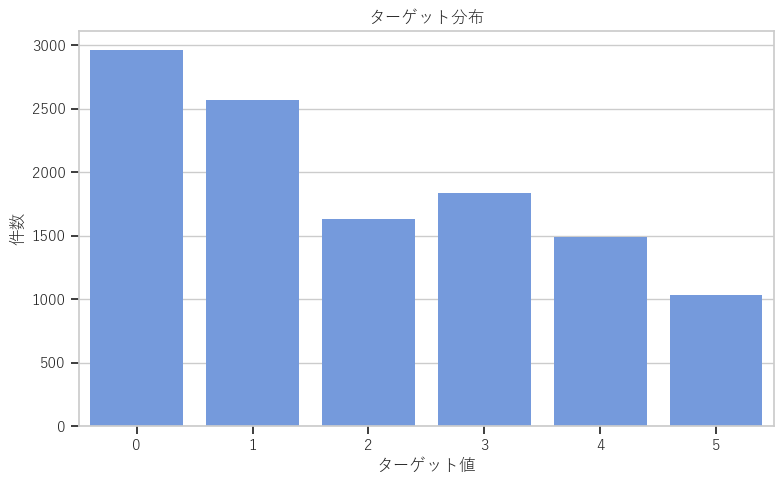

In [7]:
try:
    from pathlib import Path

    print('===== ターゲット確認 =====')
    if target_col in df.columns:
        y = pd.to_numeric(df[target_col], errors='coerce')
        print('件数:')
        print(y.value_counts(dropna=False).sort_index())
        print('\n比率(%):')
        print((y.value_counts(normalize=True, dropna=False).sort_index() * 100).round(2))

        plt.figure(figsize=(8, 5))
        vc = y.value_counts(dropna=False).sort_index()
        sns.barplot(x=vc.index.astype(str), y=vc.values, color='cornflowerblue')
        plt.xlabel('ターゲット値')
        plt.ylabel('件数')
        plt.title('ターゲット分布')
        plt.tight_layout()
        plt.savefig(Path(FIG_DIR) / 'target_distribution.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: target_code: {_eda_exc}")
    series = df[target_col]
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    if pd.api.types.is_numeric_dtype(series):
        uniq = series.dropna().nunique()
        if uniq > 20:
            sns.histplot(series.dropna(), bins=30, ax=ax[0], color="#f28e2b")
            ax[0].set_title("目的変数ヒストグラム")
            sns.boxplot(x=series.dropna(), ax=ax[1], color="#e15759")
            ax[1].set_title("目的変数ボックスプロット")
        else:
            vc = series.value_counts(dropna=False).sort_index()
            vc.plot(kind="bar", ax=ax[0], color="#f28e2b")
            ax[0].set_title("目的変数カテゴリ分布")
            (vc / vc.sum() * 100).round(2).plot(kind="bar", ax=ax[1], color="#e15759")
            ax[1].set_title("目的変数カテゴリ比率(%)")
    else:
        vc = series.astype(str).fillna("欠損").value_counts().head(20)
        vc.plot(kind="bar", ax=ax[0], color="#f28e2b")
        ax[0].set_title("目的変数カテゴリ分布")
        (vc / vc.sum() * 100).round(2).plot(kind="bar", ax=ax[1], color="#e15759")
        ax[1].set_title("目的変数カテゴリ比率(%)")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "target_distribution.png", dpi=160, bbox_inches="tight")
    plt.show()


## 6. 相関分析


===== 相関確認 =====


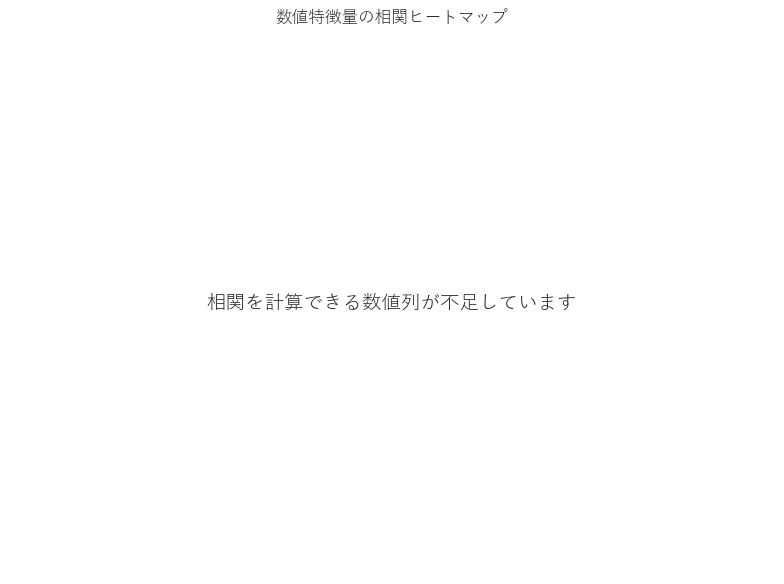

In [8]:
try:
    from pathlib import Path

    corr_df = df.copy()
    for col in corr_df.columns:
        if corr_df[col].dtype == 'object' or str(corr_df[col].dtype).startswith('category'):
            corr_df[col] = pd.to_numeric(corr_df[col], errors='ignore')

    num_df = corr_df.select_dtypes(include=[np.number]).copy()
    if target_col in corr_df.columns and target_col not in num_df.columns:
        target_num = pd.to_numeric(corr_df[target_col], errors='coerce')
        if target_num.notna().sum() > 0:
            num_df[target_col] = target_num

    print('===== 相関確認 =====')
    plt.figure(figsize=(8, 6))
    if num_df.shape[1] >= 2:
        corr = num_df.corr(numeric_only=True)
        print(corr)
        sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
        plt.title('数値特徴量の相関ヒートマップ')
    else:
        plt.text(0.5, 0.5, '相関を計算できる数値列が不足しています', ha='center', va='center', fontsize=14)
        plt.title('数値特徴量の相関ヒートマップ')
        plt.axis('off')
    plt.tight_layout()
    plt.savefig(Path(FIG_DIR) / 'feature_correlation_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: corr_code: {_eda_exc}")
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    fig, ax = plt.subplots(figsize=(10, 8))
    if len(numeric_cols) >= 2:
        corr = df[numeric_cols[:20]].corr(numeric_only=True)
        sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax)
        ax.set_title("数値特徴量の相関ヒートマップ（先頭20列）")
    else:
        ax.axis("off")
        ax.text(0.5, 0.5, "相関分析に十分な数値列がありません", ha="center", va="center", fontsize=12)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "feature_correlation_heatmap.png", dpi=160, bbox_inches="tight")
    plt.show()


## 7. 日付分析


===== 日付列確認 =====


C:\Users\hikeshita\AppData\Local\Temp\ipykernel_6848\2990452303.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(series, errors='coerce')


C:\Users\hikeshita\AppData\Local\Temp\ipykernel_6848\2990452303.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(series, errors='coerce')
C:\Users\hikeshita\AppData\Local\Temp\ipykernel_6848\2990452303.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(series, errors='coerce')
C:\Users\hikeshita\AppData\Local\Temp\ipykernel_6848\2990452303.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(series, errors='coerce')
C:\Users\hikeshita\AppData\Local\Temp\ipykernel_6848\2990452303.py:12: UserWarning

C:\Users\hikeshita\AppData\Local\Temp\ipykernel_6848\2990452303.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(series, errors='coerce')
C:\Users\hikeshita\AppData\Local\Temp\ipykernel_6848\2990452303.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(series, errors='coerce')


[warn] EDA section fallback: date_code: Invalid frequency: M. Failed to parse with error message: ValueError("'M' is no longer supported for offsets. Please use 'ME' instead.")


<Figure size 1000x500 with 0 Axes>

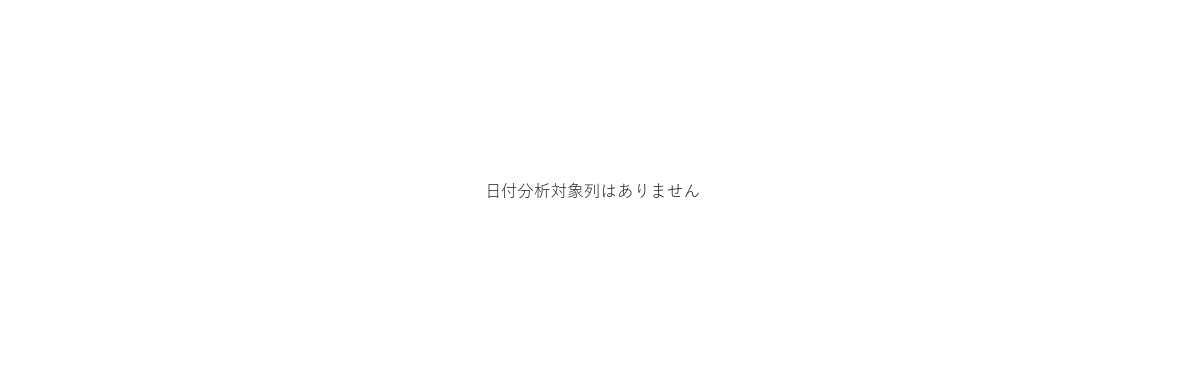

In [9]:
try:
    from pathlib import Path

    def is_pure_day_number_column(series):
        s = pd.to_numeric(series, errors='coerce')
        valid = s.dropna()
        if len(valid) == 0:
            return False
        return valid.between(1, 31).mean() > 0.95

    def try_parse_date(series):
        parsed = pd.to_datetime(series, errors='coerce')
        if parsed.notna().mean() > 0.8:
            return parsed
        return None

    print('===== 日付列確認 =====')
    candidate_cols = []
    if date_col_hint is not None and str(date_col_hint) != 'None' and date_col_hint in df.columns:
        candidate_cols.append(date_col_hint)
    for col in df.columns:
        if col not in candidate_cols:
            candidate_cols.append(col)

    selected_date_col = None
    parsed_dates = None
    for col in candidate_cols:
        if is_pure_day_number_column(df[col]):
            continue
        parsed = try_parse_date(df[col])
        if parsed is not None:
            selected_date_col = col
            parsed_dates = parsed
            break

    plt.figure(figsize=(10, 5))
    if selected_date_col is not None:
        tmp = pd.DataFrame({'date': parsed_dates})
        tmp = tmp.dropna().sort_values('date')
        trend = tmp.set_index('date').resample('M').size()
        print(f'使用日付列: {selected_date_col}')
        print(trend.head())
        plt.plot(trend.index, trend.values, marker='o')
        plt.xlabel('日付')
        plt.ylabel('件数')
        plt.title(f'{selected_date_col} の時系列推移')
        plt.xticks(rotation=45)
    else:
        plt.text(0.5, 0.5, '解析可能な日付列がありません', ha='center', va='center', fontsize=14)
        plt.title('日付特徴量の推移')
        plt.axis('off')
    plt.tight_layout()
    plt.savefig(Path(FIG_DIR) / 'date_feature_trend.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: date_code: {_eda_exc}")
    date_col = "None".strip() or date_col_hint
    fig, ax = plt.subplots(figsize=(12, 4))
    if date_col and date_col in df.columns and date_col != target_col:
        pure_day = is_pure_day_number_column(df[date_col])
        if pure_day:
            ax.axis("off")
            ax.text(0.5, 0.5, f"{date_col} は純粋な日番号列のため日付展開を行いません", ha="center", va="center", fontsize=12)
        else:
            parsed = pd.to_datetime(df[date_col], errors="coerce")
            valid = parsed.notna()
            if valid.sum() > 0:
                tmp = df.loc[valid, [target_col]].copy()
                tmp["_date"] = parsed.loc[valid]
                if pd.api.types.is_numeric_dtype(tmp[target_col]):
                    monthly = tmp.set_index("_date")[target_col].resample("M").mean()
                    monthly.plot(ax=ax, color="#4e79a7", marker="o")
                    ax.set_title("月次の目的変数平均")
                    ax.set_ylabel("平均値")
                else:
                    monthly = tmp.assign(_value=1).set_index("_date")["_value"].resample("M").sum()
                    monthly.plot(ax=ax, color="#4e79a7", marker="o")
                    ax.set_title("月次レコード件数")
                    ax.set_ylabel("件数")
                ax.set_xlabel("日付")
            else:
                ax.axis("off")
                ax.text(0.5, 0.5, f"{date_col} を日付として解釈できませんでした", ha="center", va="center", fontsize=12)
    else:
        ax.axis("off")
        ax.text(0.5, 0.5, "日付分析対象列はありません", ha="center", va="center", fontsize=12)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "date_feature_trend.png", dpi=160, bbox_inches="tight")
    plt.show()


## 8. 観察結果サマリ


In [10]:
try:
    print('===== EDAサマリー =====')
    print(f'データサイズ: {df.shape[0]} 行 × {df.shape[1]} 列')

    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    print('\n欠損のある列:')
    if len(missing) > 0:
        print(missing)

    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    print(f'\n数値列数: {len(num_cols)}')
    print(f'カテゴリ列数: {len(cat_cols)}')

    if target_col in df.columns:
        y = pd.to_numeric(df[target_col], errors='coerce')
        print('\nターゲット要約:')
        print(y.describe())
        print('\nターゲット分布:')
        print(y.value_counts().sort_index())

    high_card = df.nunique(dropna=False).sort_values(ascending=False)
    print('\nユニーク数 上位10列:')
    print(high_card.head(10))
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: summary_code: {_eda_exc}")
    summary_rows = []
    summary_rows.append(f"レコード数: {len(df):,}")
    summary_rows.append(f"列数: {df.shape[1]:,}")
    summary_rows.append(f"欠損率上位列: {', '.join((df.isna().mean()*100).sort_values(ascending=False).head(3).index.tolist())}")
    summary_rows.append(f"数値列数: {len(df.select_dtypes(include=['number']).columns)}")
    summary_rows.append(f"カテゴリ列数: {len([c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])])}")
    summary_rows.append(f"目的変数候補: {target_col}")
    print("主要サマリ")
    for row in summary_rows:
        print(f"- {row}")


===== EDAサマリー =====
データサイズ: 11529 行 × 10 列

欠損のある列:
Major         112
Experience     55
dtype: int64

数値列数: 1
カテゴリ列数: 9

ターゲット要約:
count    11529.000000
mean         1.950820
std          1.653784
min          0.000000
25%          0.000000
50%          2.000000
75%          3.000000
max          5.000000
Name: target, dtype: float64

ターゲット分布:
target
0    2963
1    2570
2    1633
3    1834
4    1492
5    1037
Name: count, dtype: int64

ユニーク数 上位10列:
id            11529
Country          58
Profession       20
Industry         19
Major            14
Experience       12
Age              12
Education         7
target            6
Gender            4
dtype: int64


C:\Users\hikeshita\AppData\Local\Temp\ipykernel_6848\2043349588.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
